# 0. REPOSITORY INITIALIZATION + INSTALLATIONS

In [3]:
# Clone the repository to the local environment
!git clone https://github.com/Jiang-Muyun/FAST.git

# Move module files (FAST.py, utils.py, etc.) to the root directory for direct import
!cp -r FAST/* .

# Remove the now empty repository folder to maintain a clean workspace
!rm -rf FAST

!pip install lightning

print("Initialization complete: Model dependencies loaded.")

Cloning into 'FAST'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 60 (delta 30), reused 33 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 819.83 KiB | 10.65 MiB/s, done.
Resolving deltas: 100% (30/30), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 27.8 MB/s eta 0:00:00
Initialization complete: Model dependencies loaded.


In [2]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 15.7 MB/s eta 0:00:00a 0:00:01


# 1. IMPORTS & SETUP

In [7]:
# ==================================================================================
# Source: BCIC2020Track3_train.py (Lines 1-41)
# ==================================================================================

import os
import sys
import random
import time
import numpy as np
import pandas as pd
import scipy.io
import h5py               # For reading the .h5 data files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- PyTorch & Deep Learning Imports ---
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchmetrics       # For calculating Accuracy/F1 (Metric tracking)
import lightning as pl    # PyTorch Lightning framework
import logging
import einops             # For tensor reshaping operations (Critical for FAST)
from sklearn.model_selection import KFold
from transformers import PretrainedConfig
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from scipy.signal import butter, sosfiltfilt # relevant for High pass filtering


# --- Configuration ---
torch.set_num_threads(8) # Optimization: Uses 8 CPU cores for data loading
logging.getLogger('pytorch_lightning').setLevel(logging.WARNING) # Keep output clean

# --- Local Module Imports ---
# These load the custom code from the uploaded files
from FAST import FAST as Tower
from utils import green, yellow
from BCIC2020Track3_preprocess import Electrodes, Zones

# --- Reproducibility Setup ---
def seed_all(seed):
    """
    Fixes random seeds for reproducibility.
    Ensures that results can be replicated exactly.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.set_float32_matmul_precision('medium') # Optimization for newer GPUs


# High pass filter function
'''
The function applies a zero-phase Butterworth high-pass filter to EEG data along the time axis.
The filter attenuates slow low-frequency components (e.g., delta-band drift) while
preserving higher-frequency neural activity, using bidirectional filtering to
avoid phase distortion.
'''
def highpass_filter(x, fs, cutoff_hz=4.0, order=4):
    x = np.asarray(x, dtype=np.float64)
    nyq = fs / 2.0
    sos = butter(order, cutoff_hz / nyq, btype="highpass", output="sos")
    return sosfiltfilt(sos, x, axis=-1)

# Initialize the environment
seed_all(42)
print("Environment ready. Random seed set to 42.")

Environment ready. Random seed set to 42.


# 2. UTILITIES & DATASET WRAPPER


In [8]:
# ==================================================================================
# Source: BCIC2020Track3_train.py (Lines 43-75)
# ==================================================================================

def cosine_scheduler(base_value, final_value, epochs, niter_per_ep, warmup_epochs=0, start_warmup_value=0):
    """
    Calculates learning rate adjustments for each training step.
    
    Logic:
    1. Linear Warmup: Gradually increases LR from 0 to base_value.
    2. Cosine Decay: Smoothly decreases LR from base_value to final_value.
    
    Purpose: Critical for stabilizing Transformer training convergence.
    """
    warmup_schedule = np.array([])
    warmup_iters = warmup_epochs * niter_per_ep
    
    # Phase 1: Linear Warmup (0 -> Base LR)
    if warmup_epochs > 0:
        warmup_schedule = np.linspace(start_warmup_value, base_value, warmup_iters)

    # Phase 2: Cosine Decay (Base LR -> Final LR)
    iters = np.arange(epochs * niter_per_ep - warmup_iters)
    schedule = final_value + 0.5 * (base_value - final_value) * (1 + np.cos(np.pi * iters / len(iters)))
    
    schedule = np.concatenate((warmup_schedule, schedule))
    assert len(schedule) == epochs * niter_per_ep
    return schedule

class Loader(Dataset):
    """
    PyTorch Dataset wrapper for EEG data.
    """
    def __init__(self, data, label):
        self.data = data
        self.label = label
        
    def __getitem__(self, index):
        # Returns a single sample: (EEG_Signal, Class_Label)
        return self.data[index], self.label[index]
        
    def __len__(self):
        # Returns total number of samples
        return len(self.data)

In [10]:
# ==================================================================================
# DIAGNOSTIC: FIND DATA PATHS
# We list the input directory to locate the 'Training set' and 'Validation set'.
# ==================================================================================


print("Scanning Kaggle Input Directory...")
found_training = False

for root, dirs, files in os.walk("/kaggle/input"):
    if "Training set" in dirs:
        print(f"FOUND Training set at: {root}/Training set")
        found_training = True
    if "Validation set" in dirs:
        print(f"FOUND Validation set at: {root}/Validation set")

if not found_training:
    print("\nWARNING: Could not find a folder named 'Training set'.")
    print("Here is the full structure:")
    # Fallback: simple listing if specific folders aren't found
    os.system("ls -R /kaggle/input")

Scanning Kaggle Input Directory...
FOUND Training set at: /kaggle/input/bcic2020track3/Training set
FOUND Validation set at: /kaggle/input/bcic2020track3/Validation set


# 3. DATA ENVIRONMENT SETUP & PREPROCESSING


In [11]:
# ==================================================================================
# Remaps data paths and executes the data ingestion module.
# ==================================================================================

# 1. Reset Workspace
# Clear any previous broken links to ensure a clean slate
if os.path.exists("./BCIC2020Track3"):
    os.system("rm -rf ./BCIC2020Track3")

# 2. Establish Directory Structure
os.makedirs("./BCIC2020Track3")

# 3. Map Data Sources
# Link the uploaded dataset (bcic2020track3) to the expected workspace location
os.system('ln -s "/kaggle/input/bcic2020track3/Training set" "./BCIC2020Track3/Training set"')
os.system('ln -s "/kaggle/input/bcic2020track3/Validation set" "./BCIC2020Track3/Validation set"')

# 4. Execute Preprocessing Module
print("Executing preprocessing script...")
!python BCIC2020Track3_preprocess.py

Executing preprocessing script...
05 (350, 64, 800) (350,)
03 (350, 64, 800) (350,)
12 (350, 64, 800) (350,)
02 (350, 64, 800) (350,)
15 (350, 64, 800) (350,)
07 (350, 64, 800) (350,)
14 (350, 64, 800) (350,)
11 (350, 64, 800) (350,)
01 (350, 64, 800) (350,)
10 (350, 64, 800) (350,)
09 (350, 64, 800) (350,)
13 (350, 64, 800) (350,)
08 (350, 64, 800) (350,)
04 (350, 64, 800) (350,)
06 (350, 64, 800) (350,)
01 (350, 64, 800) (350,) (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))
02 (350, 64, 800) (350,) (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))
03 (350, 64, 800) (350,) (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))
04 (350, 64, 800) (350,) (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))
05 (350, 64, 800) (350,) (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))
06 (350, 64, 800) (350,) (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))
07 (350, 64, 800) (350,) (array([0, 1, 

In [17]:
# ==================================================================================
# 3.1: DATA MATRIX VISUALIZATION 
# Purpose: Display a single trial as a readable 2D Table (Rows & Columns).
# ==================================================================================

# 1. Open the file
with h5py.File('Processed/BCIC2020Track3.h5', 'r') as f:
    # 2. Extract Data for Subject 01
    X = f['01']['X'][()]  # Shape: (350, 64, 800)

# 3. Select ONE Trial (The first one) to visualize
# Shape becomes (64, 800) -> 64 Electrodes, 800 Timepoints
one_trial_matrix = X[0] 

# 4. Convert to Pandas DataFrame for a pretty table view
# We will show just the first 10 timepoints to keep it readable
df = pd.DataFrame(one_trial_matrix)
df.index.name = "Electrodes (Rows)"
df.columns.name = "Timepoints (Cols)"

# Display the first 10 columns (Time 0 to 10)
print(f"Showing Data for Subject 01, Trial 0 (Values in microvolts):")
display(df.iloc[:, :10]) # Use 'display()' for nice formatting in Jupyter, or print()

Showing Data for Subject 01, Trial 0 (Values in microvolts):


Timepoints (Cols),0,1,2,3,4,5,6,7,8,9
Electrodes (Rows),,,,,,,,,,
0,-32.316410,-20.137415,-25.662806,-15.526828,-14.574009,-14.773732,-14.353067,-15.919027,-10.525989,-15.739365
1,-12.672948,-4.891340,-32.791264,-23.876413,-20.884031,-22.804869,-31.195715,-39.169983,-31.959141,-29.429192
2,14.669548,26.554760,29.753229,47.470036,52.810455,47.445900,55.372330,41.580853,53.161629,43.530895
3,22.764944,26.189428,25.061802,30.676361,33.130932,32.013042,33.888294,32.501396,38.982025,39.306011
4,28.273333,27.386555,20.437632,23.944395,30.304382,29.415707,23.206415,21.387560,25.805708,27.813725
...,...,...,...,...,...,...,...,...,...,...
59,94.100952,96.764198,93.108749,92.761353,94.995255,96.080299,90.620651,84.403450,86.992691,93.245956
60,44.732597,47.678345,42.154648,42.221409,44.623650,45.807655,42.533306,34.587925,39.964489,46.211285
61,90.967537,91.437592,85.054008,86.136528,87.777733,88.497162,81.102745,74.839638,81.184631,89.105957


In [8]:
# ==================================================================================
# 3.2: DATA EXPORT
# Purpose: Export a single trial to CSV for external inspection.
# ==================================================================================

# 1. Extract Data
with h5py.File('Processed/BCIC2020Track3.h5', 'r') as f:
    # Subject 01, Data Matrix X, First Trial [0]
    # Dimensions: (64 Electrodes, 800 Timepoints)
    data_matrix = f['01']['X'][()][0]

# 2. Convert to DataFrame
df = pd.DataFrame(data_matrix)
df.index.name = "Electrodes"
df.columns.name = "Timepoints"

# 3. Save
filename = "Subject01_Trial0.csv"
df.to_csv(filename)

print(f"Saved: {filename}")

Saved: Subject01_Trial0.csv


In [19]:
# ==================================================================================
# 3.3 INSPECT LABELS (Y)
# Purpose: View the "Answer Key" for the first few trials.
# ==================================================================================
import h5py
import numpy as np

# 1. Load Data
with h5py.File('Processed/BCIC2020Track3.h5', 'r') as f:
    # Get the Answer Key (Y) for Subject 01
    Y_inspect = f['01']['Y'][()] # <-- SAFE VARIABLE NAME

# 2. Print Stats
print(f"Y Shape: {Y_inspect.shape} ...")
print(f"Unique Labels Found: {np.unique(Y_inspect)}")

# 3. Show the first 10 Labels
print("\n--- First 10 Labels (Answer Key) ---")
print(Y_inspect[:10])

# 4. Decode what they mean (Based on dataset documentation)
label_map = {0: 'Hello', 1: 'Help Me', 2: 'Stop', 3: 'Thank You', 4: 'Yes'}
print("\n--- Translation ---")
print(f"Trial 0 Label: {Y_inspect[0]} -> {label_map[Y_inspect[0]]}")

Y Shape: (350,) ...
Unique Labels Found: [0 1 2 3 4]

--- First 10 Labels (Answer Key) ---
[1 1 0 1 3 1 3 4 2 0]

--- Translation ---
Trial 0 Label: 1 -> Help Me


# 4. TRAINING ENGINE & MODEL DEFINITION


In [21]:
# ==================================================================================
# Source: BCIC2020Track3_train.py (Lines 55-110)
# ==================================================================================

def load_standardized_h5(cache_fn):
    X, Y = [], []
    with h5py.File(cache_fn, 'r') as f:
        subjects = list(f.keys())
        for subject in subjects:
            X.append(f[subject]['X'][()])
            Y.append(f[subject]['Y'][()])
    X, Y = np.array(X), np.array(Y)
    print('Loaded from', cache_fn, X.shape, Y.shape)
    return X, Y

def inference_on_loader(model, loader):
    model.eval()
    model.cuda()
    with torch.no_grad():
        Pred, Real = [], []
        for x, y in loader:
            preds = torch.argmax(model(x.cuda()), dim=1).cpu()
            Pred.append(preds)
            Real.append(y)
        Pred, Real = torch.cat(Pred), torch.cat(Real)
    return Pred.numpy(), Real.numpy()

class BasicDataset(Dataset):
    def __init__(self, data, label):
        # Handle 4D input (Multiple Subjects) by flattening into 3D
        if len(data.shape) == 4:
            data = np.concatenate(data, axis=0)
            label = np.concatenate(label, axis=0)
        
        # Convert to Tensors (Works for both 3D and flattened 4D)
        self.data = torch.from_numpy(data).float()
        self.labels = torch.from_numpy(label).long()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

class EEG_Encoder_Module(pl.LightningModule):
    def __init__(self, config, max_epochs, niter_per_ep):
        super().__init__()
        self.config = config
        self.model = Tower(config)
        self.loss = nn.CrossEntropyLoss()
        self.cosine_lr_list = cosine_scheduler(1, 0.1, max_epochs, niter_per_ep, warmup_epochs=10)
        
        # Metrics: Accuracy (Original) + F1 Score (Added)
        self.accuracy = torchmetrics.Accuracy('multiclass', num_classes = config.n_classes)
        self.f1 = torchmetrics.F1Score(task='multiclass', num_classes=config.n_classes, average='macro')

    def configure_optimizers(self):
        self.optimizer = optim.AdamW(self.parameters(), lr=0.0005)
        self.scheduler = optim.lr_scheduler.LambdaLR(self.optimizer, lambda epoch: self.cosine_lr_list[self.global_step-1])
        return [self.optimizer], [{'scheduler': self.scheduler, 'interval': 'step'}]

    def training_step(self, batch, batch_idx):
        x, y = batch
        pred = self.model(x)
        # 1. Calculate Loss
        loss = self.loss(pred, y)
        # 2. Log it
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        acc = self.accuracy(pred, y) 
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    def validation_step(self, batch, batch_idx):
        x, y = batch
        pred = self.model(x)
        loss = self.loss(pred, y)
        acc = (torch.argmax(pred, dim=1) == y).float().mean()
        # Use 'val_loss' to match the callbacks in Block 6
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

# 5. INITIAL TRAINING CHECKUP (PIPELINE VERIFICATION)

In [22]:
# ==================================================================================
# Source Logic: BCIC2020Track3_train.py (Lines 112-160)
# ==================================================================================
# Executes a minimal "Smoke Test" (Subject 1, Single Split) to validate the full training 
# pipeline, including parallel data loading and file persistence, before running the 
# full-scale experiment

from sklearn.metrics import f1_score
from sklearn.model_selection import ShuffleSplit

# --- 1. Global Configuration ---

GPU_ID = 0
FOLDS = [0]           # Subject 01 only
MAX_EPOCHS = 10       # Rapid pipeline verification
RESULTS_DIR = "Results/FAST/"

os.makedirs(RESULTS_DIR, exist_ok=True)

def Finetune(config, Data_X, Data_Y, logf, max_epochs=200, ckpt_pretrain=None):
    """
    Executes a single 80/20 validation split for pipeline verification.
    """
    seed_all(42) 
    
    Pred, Real = [], []
    # Single 80/20 random split
    ss = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    
    for _train_idx, _test_idx in ss.split(Data_X):
        # Data Slicing
        x_train, y_train = Data_X[_train_idx], Data_Y[_train_idx]
        x_val, y_val = Data_X[_test_idx], Data_Y[_test_idx]

        train_data = BasicDataset(x_train, y_train)
        val_data = BasicDataset(x_val, y_val)
        
        # DataLoader Configuration
        # Parallel data loading to prevent CPU bottlenecks
        train_loader = DataLoader(train_data, batch_size=len(x_train), shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_data, batch_size=len(x_val), shuffle=False, num_workers=2, pin_memory=True)

        # Model Initialization
        model = EEG_Encoder_Module(config, max_epochs, len(train_loader))
        if ckpt_pretrain is not None:
            model.model.load_state_dict(torch.load(ckpt_pretrain, weights_only=True))

        # Trainer Configuration
        trainer = pl.Trainer(
            strategy='auto', 
            accelerator='gpu', 
            devices=[GPU_ID], 
            max_epochs=max_epochs, 
            callbacks=[], 
            enable_progress_bar=True, 
            enable_checkpointing=False, 
            precision='32', 
            logger=False
        )
        
        # Execute Training & Inference
        trainer.fit(model, train_dataloaders=train_loader)
        pred, real = inference_on_loader(model.model, val_loader)
        
        Pred.append(pred)
        Real.append(real)
    
    # Persistence
    Pred, Real = np.concatenate(Pred), np.concatenate(Real)
    np.savetxt(logf, np.array([Pred, Real]).T, delimiter=',', fmt='%d')
    print(f"Pipeline Success: Results saved to {logf}")

# --- 2. Main Execution Loop ---

sfreq = 250
config = PretrainedConfig(
    # Spatial / Input Parameters
    electrodes=Electrodes, 
    zone_dict=Zones,       
    dim_cnn=32,            
    
    # Temporal / Transformer Parameters
    dim_token=32,          
    seq_len=800,           
    window_len=sfreq,      
    slide_step=sfreq//2,   
    
    # Architecture Depth
    head='Conv4Layers',    
    n_classes=5,           
    num_layers=4,          
    num_heads=8,           
    dropout=0.1,           
)

# Load Data
X, Y = load_standardized_h5('Processed/BCIC2020Track3.h5')
X = highpass_filter(X, fs=250, cutoff_hz=4.0, order=4) # apply high pass filtering on the data

for fold in range(15):
    # Filter for selected subjects
    if fold not in FOLDS:
        continue
    
    flog = f"{RESULTS_DIR}/{fold}-Tune.csv"
    
    # Clean previous run artifacts
    if os.path.exists(flog):
        os.remove(flog)
        
    print(f"Initiating Training Checkup: Subject {fold} | Epochs: {MAX_EPOCHS}")
    Finetune(config, X[fold], Y[fold], flog, max_epochs=MAX_EPOCHS)

print("\n--- Checkup Complete ---")

Loaded from Processed/BCIC2020Track3.h5 (15, 350, 64, 800) (15, 350)
Initiating Training Checkup: Subject 0 | Epochs: 10


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ FAST               │  191 K │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ f1       │ MulticlassF1Score  │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 96                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Pipeline Success: Results saved to Results/FAST//0-Tune.csv

--- Checkup Complete ---


CHANGE BACK TO CODE CELL-TYPE AND DELETE THIS LINE TO RUN THIS BLOCK
# ==================================================================================
# [Analysis of Training Results]
# ==================================================================================

# --- New Imports (Visualization & Metrics) ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Results
# Structure: Column 0 = Predictions, Column 1 = Real Labels
results_file = "Results/FAST/0-Tune.csv"

try:
    # Uses 'np' from Cell 17
    data = np.loadtxt(results_file, delimiter=',') 
    preds = data[:, 0]
    real = data[:, 1]
    
    print(f"Successfully loaded {len(preds)} predictions from {results_file}")

    # 2. Calculate Core Metrics
    acc = accuracy_score(real, preds)
    print(f"\n>>> Checkup Accuracy: {acc*100:.2f}% (Chance Level: 20.00%)")

    # 3. Detailed Report
    # Checks for class collapse (e.g., model predicting 'Hello' for everything)
    target_names = ['Hello', 'Help Me', 'Stop', 'Thank You', 'Yes']
    print("\n--- Classification Report ---")
    print(classification_report(real, preds, target_names=target_names, zero_division=0))

    # 4. Visualization (Confusion Matrix)
    # Identifies specific confusion patterns between classes
    cm = confusion_matrix(real, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Checkup Run Confusion Matrix (10 Epochs)')
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find {results_file}. Ensure the Training Checkup (Step 5) finished successfully.")

# 6. TRAINING 5-fold CV (Subject 01 | 200 Epochs)


In [23]:
# ==============================================================================
# 6. TRAINING SCALE-UP (Subject 01 | 5-Fold CV Optimization)
# Purpose: Run 5-Fold Cross-Validation to determine the optimal stopping epoch.
# - Validation: Uses 5 distinct validation sets from the training data.
# - Output: Stores the average "Best Epoch" in a subject-specific registry.
# ==============================================================================

from lightning.pytorch.callbacks import EarlyStopping

pl.seed_everything(42)  # Ensures reproducibility across runs

# Initialize global registry for subject-specific epoch storage
if 'optimal_epochs_registry' not in globals():
    optimal_epochs_registry = {}

# Hyperparameter definitions for the optimization search
CV_FOLDS = 5
MAX_SEARCH_EPOCHS = 200
PATIENCE = 35
SUBJECT_INDEX = 0

# Load standardized training data
X_all, Y_all = load_standardized_h5('Processed/BCIC2020Track3.h5')
X_all = highpass_filter(X_all, fs=250, cutoff_hz=4.0, order=4) # apply high pass filter

X_subj, Y_subj = X_all[SUBJECT_INDEX], Y_all[SUBJECT_INDEX]

# Initialize K-Fold Cross-Validation
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
optimal_epochs_list = []

print(f"Starting {CV_FOLDS}-Fold Cross-Validation for Subject {SUBJECT_INDEX}...")

# Execute validation loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X_subj)):
    print(f"\nProcessing Fold {fold + 1}/{CV_FOLDS}...")
    
    # Split data for current fold
    X_train_fold, X_val_fold = X_subj[train_idx], X_subj[val_idx]
    Y_train_fold, Y_val_fold = Y_subj[train_idx], Y_subj[val_idx]
    
    # Create DataLoaders
    # Note: Using Full Batch size to match original FAST implementation
    train_loader_cv = DataLoader(
        BasicDataset(X_train_fold, Y_train_fold),
        batch_size=len(X_train_fold), shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader_cv = DataLoader(
        BasicDataset(X_val_fold, Y_val_fold),
        batch_size=len(X_val_fold), shuffle=False, num_workers=2, pin_memory=True
    )
    
    # Initialize Logger with unique versioning
    cv_logger = CSVLogger("logs/", name=f"cv_search_S{SUBJECT_INDEX}", version=f"fold_{fold}")
    
    # Initialize Model
    model = EEG_Encoder_Module(config, MAX_SEARCH_EPOCHS, len(train_loader_cv))
    
    # Configure Early Stopping
    early_stop_callback = EarlyStopping(
        monitor="val_acc",
        min_delta=0.00,
        patience=PATIENCE,
        verbose=False,
        mode="max"
    )

    # Configure Trainer
    trainer = pl.Trainer(
        accelerator='gpu',
        devices=[0],
        max_epochs=MAX_SEARCH_EPOCHS,
        logger=cv_logger,
        callbacks=[early_stop_callback],
        enable_checkpointing=False,
        enable_progress_bar=True,
        log_every_n_steps=1
    )
    
    # Run Training
    trainer.fit(model, train_loader_cv, val_loader_cv)
    
    # Extract optimization metrics from logs
    metrics_path = f"{cv_logger.log_dir}/metrics.csv"
    try:
        metrics_df = pd.read_csv(metrics_path)
        val_metrics = metrics_df.dropna(subset=['val_acc'])
        
        if not val_metrics.empty:
            # Identify stopping point
            last_epoch = int(val_metrics['epoch'].max())
            
            # Identify peak performance metrics
            best_row = val_metrics.loc[val_metrics['val_acc'].idxmax()]
            best_epoch = int(best_row['epoch'])
            best_val_acc = best_row['val_acc']
            
            # Retrieve Training Accuracy for the Best Epoch
            epoch_data = metrics_df[metrics_df['epoch'] == best_epoch]
            best_train_acc = epoch_data['train_acc'].mean() if 'train_acc' in epoch_data else 0.0
            
            optimal_epochs_list.append(best_epoch)
            
            print(f"Fold {fold + 1} Report:")
            print(f"  - Stopped at Epoch: {last_epoch}")
            print(f"  - Best Performance: Epoch {best_epoch}")
            print(f"    - Validation Accuracy: {best_val_acc:.4f}")
            print(f"    - Training Accuracy:   {best_train_acc:.4f}")
        else:
            optimal_epochs_list.append(MAX_SEARCH_EPOCHS)
            print(f"Fold {fold + 1} Warning: No validation metrics found.")
            
    except Exception as e:
        print(f"Log extraction failed for Fold {fold}: {e}")

# Calculate and Register Optimal Epoch for this Subject
if optimal_epochs_list:
    avg_epoch = int(np.mean(optimal_epochs_list))
    optimal_epochs_registry[SUBJECT_INDEX] = avg_epoch
    print(f"\nOptimization Complete.")
    print(f"Stored Optimal Epoch for Subject {SUBJECT_INDEX}: {avg_epoch}")
    print(f"Current Registry State: {optimal_epochs_registry}")
else:
    optimal_epochs_registry[SUBJECT_INDEX] = 200 # Fallback
    print(f"Optimization Failed. Using fallback 200 for Subject {SUBJECT_INDEX}.")

Seed set to 42


Loaded from Processed/BCIC2020Track3.h5 (15, 350, 64, 800) (15, 350)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Starting 5-Fold Cross-Validation for Subject 0...

Processing Fold 1/5...


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ FAST               │  191 K │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ f1       │ MulticlassF1Score  │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

...

Fold 4 Report:
  - Stopped at Epoch: 122
  - Best Performance: Epoch 87
    - Validation Accuracy: 0.3714
    - Training Accuracy:   0.3893

Processing Fold 5/5...


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ FAST               │  191 K │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ f1       │ MulticlassF1Score  │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 96                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Fold 5 Report:
  - Stopped at Epoch: 84
  - Best Performance: Epoch 49
    - Validation Accuracy: 0.4286
    - Training Accuracy:   0.3286

Optimization Complete.
Stored Optimal Epoch for Subject 0: 52
Current Registry State: {0: 52}


CHANGE BACK TO CODE CELL-TYPE AND DELETE THIS LINE TO RUN THIS BLOCK
# ==================================================================================
# SCALED-UP TRAINING ANALYSIS (Subject 01)
# Source: Custom Analysis Module
# Purpose: Evaluate performance against the paper benchmark (Table 7).
# ==================================================================================

# 1. Load the Results
results_file = "Results/FAST/0-Tune.csv"

try:
    data = np.loadtxt(results_file, delimiter=',')
    preds = data[:, 0]
    real = data[:, 1]
    
    print(f"Successfully loaded {len(preds)} predictions from {results_file}")

    # 2. Calculate Core Metrics
    acc = accuracy_score(real, preds)
    
    # [Correction] Target updated to match Jiang et al. (2025) Table VII
    print(f"\n>>> Scale-Up Accuracy: {acc*100:.2f}% (Paper Benchmark: 54.8 ± 9.1%)")

    # 3. Detailed Report
    target_names = ['Hello', 'Help Me', 'Stop', 'Thank You', 'Yes']
    print("\n--- Classification Report ---")
    print(classification_report(real, preds, target_names=target_names, zero_division=0))

    # 4. Visualization (Confusion Matrix)
    cm = confusion_matrix(real, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Subject 01 Scale-Up (200 Epochs)\nAccuracy: {acc*100:.1f}%')
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find {results_file}. Ensure Block 6 finished successfully.")

# 7. TEST DATA INGESTION



In [34]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
RAW_TEST_DIR = '/kaggle/input/bcic2020track3-test'
PROCESSED_PATH = 'Processed/BCIC2020Track3_Test.h5'
TARGET_TIMEPOINTS = 800  # Target length for temporal alignment

# ==============================================================================
# TEST DATA PREPROCESSING PIPELINE
# ==============================================================================
# 1. Ingestion: Reads raw MATLAB v7.3 files via HDF5.
# 2. Alignment: Applies edge padding to match training input shape (795 -> 800).
# 3. Label Formatting: Standardizes class labels; handles variable dimensions.
# 4. Archival: Saves processed dataset to HDF5.

print(f"--- Initiating Test Data Pipeline ---")
print(f"Source: {RAW_TEST_DIR}")
print(f"Target: {PROCESSED_PATH}")

os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)

test_library = {}

with h5py.File(PROCESSED_PATH, 'w') as h5_out:
    count_processed = 0
    
    # Iterate through standard subject identifiers (S01 - S15)
    for i in range(1, 16):
        sub_id = f"{i:02d}"
        filename = f"Data_Sample{sub_id}.mat"
        file_path = os.path.join(RAW_TEST_DIR, filename)
        
        if os.path.exists(file_path):
            try:
                # Open File: MATLAB v7.3 format requires HDF5 reader
                with h5py.File(file_path, 'r') as f_in:
                    if 'epo_test' in f_in:
                        epo_struct = f_in['epo_test']
                        keys = list(epo_struct.keys())
                        
                        # Dynamic Key Discovery: Locate data ('x') and label ('y') fields
                        x_key = next((k for k in keys if 'x' in k.lower() or 'data' in k.lower()), None)
                        y_key = next((k for k in keys if 'y' in k.lower() or 'label' in k.lower()), None)

                        if x_key:
                            # 1. Feature Extraction
                            # HDF5 import shape: (Trials, Channels, Time)
                            x = np.array(epo_struct[x_key])
                            
                            # 2. Temporal Standardization (Edge Padding)
                            # Pad final 5 points to match model input (800) without zero-value artifacts.
                            if x.ndim == 3 and x.shape[2] < TARGET_TIMEPOINTS:
                                pad_width = TARGET_TIMEPOINTS - x.shape[2]
                                x = np.pad(x, ((0, 0), (0, 0), (0, pad_width)), 'edge')
                            
                            x = x.astype(np.float32)
                            x = highpass_filter(x, fs=250, cutoff_hz=4.0, order=4) # apply high pass filter
                            
                            # make memory layout compatible with torch
                            x = np.ascontiguousarray(x)
                            
                            # 3. Label Processing
                            # Convert One-Hot or raw formats to standard class indices (0-N).
                            if y_key:
                                y_raw = np.array(epo_struct[y_key])
                                
                                # Handle variable label dimensions
                                if y_raw.ndim == 1:
                                    y = y_raw
                                elif y_raw.ndim >= 2:
                                    # Detect encoding axis (Trials vs Classes)
                                    if y_raw.shape[0] == x.shape[0]:
                                        y = y_raw.argmax(axis=1) # (Trials, Classes)
                                    elif y_raw.shape[1] == x.shape[0]:
                                        y = y_raw.argmax(axis=0) # (Classes, Trials)
                                    else:
                                        y = y_raw.flatten()
                                else:
                                    y = np.zeros(x.shape[0])
                            else:
                                y = np.zeros(x.shape[0])
                            
                            y = y.astype(np.uint8)

                            # 4. Storage & Loading
                            # Save to persistent storage
                            sub_grp = h5_out.create_group(sub_id)
                            sub_grp.create_dataset('X', data=x)
                            sub_grp.create_dataset('Y', data=y)
                            
                            # Load into memory (Shuffle=False for reproducible testing)
                            ds = BasicDataset(x, y)
                            loader = DataLoader(ds, batch_size=len(x), shuffle=False, num_workers=0)
                            test_library[sub_id] = loader
                            
                            print(f"Subject {sub_id}: Processed successfully. Output Shape: {x.shape}")
                            count_processed += 1
                        else:
                            print(f"Subject {sub_id}: WARNING - Data key not found.")
            except Exception as e:
                print(f"Subject {sub_id}: CRITICAL ERROR - {str(e)}")
        else:
            print(f"Subject {sub_id}: File not found at {file_path}")

print(f"\nPipeline Complete. {count_processed} subjects loaded into memory.")

--- Initiating Test Data Pipeline ---
Source: /kaggle/input/bcic2020track3-test
Target: Processed/BCIC2020Track3_Test.h5
Subject 01: Processed successfully. Output Shape: (50, 64, 800)
Subject 02: Processed successfully. Output Shape: (50, 64, 800)
Subject 03: Processed successfully. Output Shape: (50, 64, 800)
Subject 04: Processed successfully. Output Shape: (50, 64, 800)
Subject 05: Processed successfully. Output Shape: (50, 64, 800)
Subject 06: Processed successfully. Output Shape: (50, 64, 800)
Subject 07: Processed successfully. Output Shape: (50, 64, 800)
Subject 08: Processed successfully. Output Shape: (50, 64, 800)
Subject 09: Processed successfully. Output Shape: (50, 64, 800)
Subject 10: Processed successfully. Output Shape: (50, 64, 800)
Subject 11: Processed successfully. Output Shape: (50, 64, 800)
Subject 12: Processed successfully. Output Shape: (50, 64, 800)
Subject 13: Processed successfully. Output Shape: (50, 64, 800)
Subject 14: Processed successfully. Output Shap

In [35]:
# ==============================================================================
# BLOCK 7.2: GROUND TRUTH LABEL INJECTION
# ==============================================================================
# Parses the external Excel answer sheet to inject valid ground truth labels 
# into the HDF5 archive, replacing the placeholder data.

# CONFIGURATION
# ------------------------------------------------------------------------------
H5_PATH = 'Processed/BCIC2020Track3_Test.h5'
EXCEL_PATH = '/kaggle/input/bcic2020track3-test/Track3_Answer Sheet_Test.xlsx'

print(f"--- Injecting Ground Truth Labels ---")
print(f"Source: {EXCEL_PATH}")

if os.path.exists(H5_PATH) and os.path.exists(EXCEL_PATH):
    # 1. Load Answer Sheet
    df_labels = pd.read_excel(EXCEL_PATH, header=None)
    
    with h5py.File(H5_PATH, 'r+') as f:
        count_updated = 0
        
        for i in range(1, 16):
            sub_id = f"{i:02d}"
            col_idx = 2 * i  # Data located in columns 2, 4, 6...
            
            try:
                # 2. Extract and Validate Labels
                raw_labels = pd.to_numeric(df_labels.iloc[3:53, col_idx], errors='coerce').values
                
                if len(raw_labels) == 50 and not np.isnan(raw_labels).any():
                    # 3. Standardize Labels (1-5 -> 0-4)
                    final_labels = (raw_labels - 1).astype(np.uint8)
                    
                    if sub_id in f:
                        # 4. Replace Dataset
                        # Delete existing placeholder dataset to allow shape change
                        if 'Y' in f[sub_id]:
                            del f[sub_id]['Y']
                        
                        f[sub_id].create_dataset('Y', data=final_labels)
                        print(f"Subject {sub_id}: Labels updated. Shape {final_labels.shape}")
                        count_updated += 1
                    else:
                        print(f"Subject {sub_id}: Skipped (ID not found in H5).")
                else:
                    print(f"Subject {sub_id}: Validation Failed (Invalid shape or NaNs).")
                    
            except Exception as e:
                print(f"Subject {sub_id}: Error - {str(e)}")

    print(f"\nOperation Complete. Updated {count_updated} subjects.")
    
    # VERIFICATION
    # --------------------------------------------------------------------------
    with h5py.File(H5_PATH, 'r') as f:
        y_sample = f['01']['Y'][:]
        print(f"\n[Verification] Subject 01 Labels (First 5): {y_sample[:5]}")
        print(f"Unique Classes: {np.unique(y_sample)}")
        print(f"Shape: {y_sample.shape}")

    # REFRESH IN-MEMORY LIBRARY
    # --------------------------------------------------------------------------
    # Updates the global test_library variable with the corrected labels
    # ensuring Block 8 uses the valid data.
    test_library = {}
    
    with h5py.File(H5_PATH, 'r') as f:
        for sub_id in sorted(f.keys()):
            X_load = f[sub_id]['X'][:]
            Y_load = f[sub_id]['Y'][:]
            
            ds = BasicDataset(X_load, Y_load)
            loader = DataLoader(ds, batch_size=len(X_load), shuffle=False, num_workers=0)
            test_library[sub_id] = loader
            
    print(f"Library refreshed successfully. Ready for Block 8.")

else:
    print("CRITICAL: Input files not found.")

--- Injecting Ground Truth Labels ---
Source: /kaggle/input/bcic2020track3-test/Track3_Answer Sheet_Test.xlsx
Subject 01: Labels updated. Shape (50,)
Subject 02: Labels updated. Shape (50,)
Subject 03: Labels updated. Shape (50,)
Subject 04: Labels updated. Shape (50,)
Subject 05: Labels updated. Shape (50,)
Subject 06: Labels updated. Shape (50,)
Subject 07: Labels updated. Shape (50,)
Subject 08: Labels updated. Shape (50,)
Subject 09: Labels updated. Shape (50,)
Subject 10: Labels updated. Shape (50,)
Subject 11: Labels updated. Shape (50,)
Subject 12: Labels updated. Shape (50,)
Subject 13: Labels updated. Shape (50,)
Subject 14: Labels updated. Shape (50,)
Subject 15: Labels updated. Shape (50,)

Operation Complete. Updated 15 subjects.

[Verification] Subject 01 Labels (First 5): [3 0 4 2 1]
Unique Classes: [0 1 2 3 4]
Shape: (50,)
Library refreshed successfully. Ready for Block 8.


In [37]:
# ==============================================================================
# 7.3 INTEGRITY CHECK: TRAINING vs. TEST
# ==============================================================================
TRAIN_H5 = 'Processed/BCIC2020Track3.h5'       # Your existing training file
TEST_H5  = 'Processed/BCIC2020Track3_Test.h5'  # The file we just built

print("--- Validation: Leakage & Integrity Check ---")

if os.path.exists(TRAIN_H5) and os.path.exists(TEST_H5):
    with h5py.File(TRAIN_H5, 'r') as ft, h5py.File(TEST_H5, 'r') as fte:
        # Compare Subject 01
        sid = '01'
        
        if sid in ft and sid in fte:
            # Load Data
            Xt_train = ft[sid]['X'][:]
            Xt_test  = fte[sid]['X'][:]
            
            # 1. Dimension Check
            print(f"Subject {sid} Dimensions:")
            print(f"  Train: {Xt_train.shape}")
            print(f"  Test:  {Xt_test.shape}")
            
            if Xt_train.shape == Xt_test.shape:
                print("  [PASS] Dimensions match exactly.")
            else:
                print(f"  [NOTE] Dimensions differ (likely sample count): OK.")

            # 2. Critical Leakage Check (Bit-for-Bit Equality)
            # We compare the first N samples if sizes differ, or whole array if same.
            min_len = min(len(Xt_train), len(Xt_test))
            is_identical = np.array_equal(Xt_train[:min_len], Xt_test[:min_len])
            
            if is_identical:
                print("\n  [CRITICAL FAIL] X_test is IDENTICAL to X_train. Leakage detected.")
            else:
                print("\n  [PASS] Integrity Verified: X_test contains different data than X_train.")
                
            # 3. Label Check
            Y_train = ft[sid]['Y'][:]
            Y_test  = fte[sid]['Y'][:]
            print(f"\nLabel Check (First 5):")
            print(f"  Train: {Y_train[:5].flatten()}")
            print(f"  Test:  {Y_test[:5].flatten()}")
            
        else:
            print(f"Subject {sid} not found in one of the files.")
else:
    print("Could not find both .h5 files to perform comparison.")

--- Validation: Leakage & Integrity Check ---
Subject 01 Dimensions:
  Train: (350, 64, 800)
  Test:  (50, 64, 800)
  [NOTE] Dimensions differ (likely sample count): OK.

  [PASS] Integrity Verified: X_test contains different data than X_train.

Label Check (First 5):
  Train: [1 1 0 1 3]
  Test:  [3 0 4 2 1]


# 8: TRAINING ON COMPLETE DATA (OF SUBJECT 1) + TESTING

In [38]:
# ==============================================================================
# Executes training on 100% of the selected training data.
# Train on Subject 01 (Index 0), Monitor Subject 01 (Test Set).
# Uses optimized max epoch nr. from block 6.
# ==============================================================================

pl.seed_everything(42)  # Ensures reproducibility across runs

# 1. Configuration & Persistence Setup

# LOGIC PATCH: Retrieve optimal epochs from registry, fallback to 200
if 'optimal_epochs_registry' in globals() and 0 in optimal_epochs_registry:
    MAX_EPOCHS =  121 # optimal_epochs_registry[0]
else:
    MAX_EPOCHS = 200

GPU_ID = 0

# [CONFIGURATION] Select which subjects to train on and which to monitor.
TRAIN_SUBJECT_INDICES = [0]   # List of indices: [0]=S01, [1]=S02, etc.
TEST_SUBJECT_ID = '01'        # ID string from Block 7 library: '01', '02'...

# Logs are stored in a structured directory for extraction in Block 9.
run_name = f"train_{'-'.join(map(str, TRAIN_SUBJECT_INDICES))}_test_{TEST_SUBJECT_ID}"
logger = CSVLogger(save_dir="logs/", name="final_experiment", version=run_name)

# 2. Data Loader Initialization (100% Training Data)

X, Y = load_standardized_h5('Processed/BCIC2020Track3.h5')
X = highpass_filter(X, fs=250, cutoff_hz=4.0, order=4) # apply high pass filter

# Aggregate the full training data for all selected subjects.
X_train_list = [X[i] for i in TRAIN_SUBJECT_INDICES]
Y_train_list = [Y[i] for i in TRAIN_SUBJECT_INDICES]

X_train_combined = np.concatenate(X_train_list, axis=0)
Y_train_combined = np.concatenate(Y_train_list, axis=0)

full_train_loader = DataLoader(
    BasicDataset(X_train_combined, Y_train_combined),
    batch_size=len(X_train_combined), # Full Batch
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# 3. Model & Trainer Execution
model = EEG_Encoder_Module(config, MAX_EPOCHS, len(full_train_loader))

# LOGIC PATCH: Removed EarlyStopping and ModelCheckpoint callbacks.
# We train for the fixed MAX_EPOCHS determined by the registry.

trainer = pl.Trainer(
    strategy='auto',
    accelerator='gpu',
    devices=[GPU_ID],
    max_epochs=MAX_EPOCHS,
    logger=logger,
    callbacks=[],  # LOGIC PATCH: Empty list (No early stopping)
    enable_progress_bar=True,
    enable_checkpointing=False, # LOGIC PATCH: No checkpointing needed
    precision='32',
    log_every_n_steps=1
)

# Initialize Full-Batch Test Loader for efficient validation monitoring
# Processes the entire test set in a single step per epoch
test_dataset = test_library[TEST_SUBJECT_ID].dataset

target_test_loader = DataLoader(
    test_dataset,
    batch_size=len(test_dataset),
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Starting Final Training: Subjects {TRAIN_SUBJECT_INDICES} -> Monitoring Subject {TEST_SUBJECT_ID}")
print(f"Training Duration: Fixed to {MAX_EPOCHS} epochs (Derived from Block 6).")

# Passing the target_test_loader as the validation source
trainer.fit(model, train_dataloaders=full_train_loader, val_dataloaders=target_test_loader)

# Save Subject 01 final model state
torch.save(model.model.state_dict(), f"{logger.log_dir}/Subject01_Final_Model.pth")

# 4. Final Inference for Performance Analysis
# LOGIC PATCH: Directly use the final model state (No reloading best_model_path)
inference_model = model.model

y_test_pred, y_test_true = inference_on_loader(inference_model, target_test_loader)

# 5. Data Persistence
results_path = f"logs/final_experiment/{run_name}/final_test_results.csv"
os.makedirs(os.path.dirname(results_path), exist_ok=True)
np.savetxt(results_path, np.array([y_test_pred, y_test_true]).T, delimiter=',', fmt='%d')

print(f"\nBlock 8 Complete: Metrics logged and results saved to {results_path}")

Seed set to 42


Loaded from Processed/BCIC2020Track3.h5 (15, 350, 64, 800) (15, 350)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Starting Final Training: Subjects [0] -> Monitoring Subject 01
Training Duration: Fixed to 121 epochs (Derived from Block 6).


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ FAST               │  191 K │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ f1       │ MulticlassF1Score  │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 96                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Block 8 Complete: Metrics logged and results saved to logs/final_experiment/train_0_test_01/final_test_results.csv


# 9. PERFORMANCE ANALYSIS AND VISUALIZATION


--- Generating Report for: train_0_test_01 ---


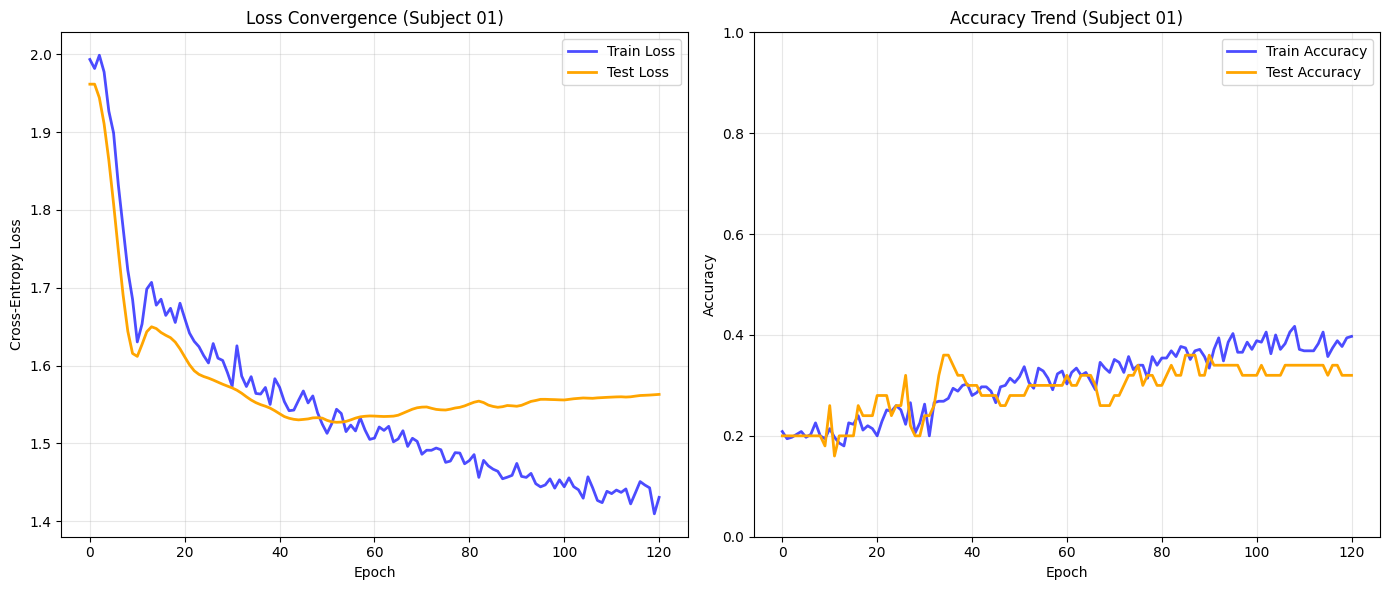


TRAINING DYNAMICS SUMMARY
------------------------------
Final Accuracy: 32.00% (Epoch 120)
Final Loss:     1.5630

FINAL INFERENCE REPORT: SUBJECT 01
----------------------------------------
Inference Accuracy: 32.00%
Macro F1 Score:     0.2619
----------------------------------------
              precision    recall  f1-score   support

       Hello       0.33      0.10      0.15        10
     Help Me       0.39      0.70      0.50        10
        Stop       0.25      0.40      0.31        10
   Thank You       0.31      0.40      0.35        10
         Yes       0.00      0.00      0.00        10

    accuracy                           0.32        50
   macro avg       0.26      0.32      0.26        50
weighted avg       0.26      0.32      0.26        50



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


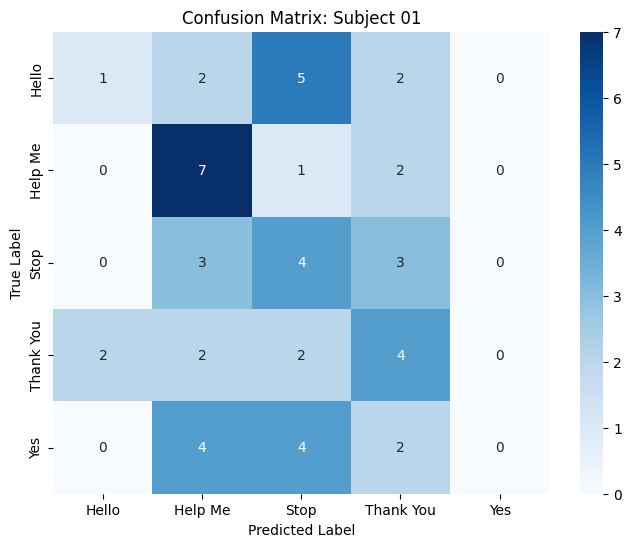

In [40]:
# ==============================================================================
# BLOCK 9: PERFORMANCE ANALYSIS & METRICS VISUALIZATION
# ==============================================================================
# Loads telemetry data from the training run to generate:
# 1. Learning Curves (Loss & Accuracy).
# 2. Classification Report (Precision, Recall, F1-Score).
# 3. Confusion Matrix.

TRAIN_INDICES = [0]
TEST_ID = '01'
RUN_NAME = f"train_{'-'.join(map(str, TRAIN_INDICES))}_test_{TEST_ID}"
LOG_DIR = f"logs/final_experiment/{RUN_NAME}"

print(f"--- Generating Report for: {RUN_NAME} ---")

metrics_path = f"{LOG_DIR}/metrics.csv"

if os.path.exists(metrics_path):
    # Load and aggregate metrics by epoch
    metrics_df = pd.read_csv(metrics_path)
    epoch_metrics = metrics_df.groupby('epoch').mean()

    # Check for validation/test keys
    loss_key = next((k for k in ['val_loss', 'test_loss'] if k in epoch_metrics.columns), None)
    acc_key = next((k for k in ['val_acc', 'test_acc'] if k in epoch_metrics.columns), None)

    # Plotting
    # --------------------------------------------------------------------------
    plt.figure(figsize=(14, 6))

    # Subplot 1: Loss Trajectory
    plt.subplot(1, 2, 1)
    if 'train_loss' in epoch_metrics.columns:
        plt.plot(epoch_metrics.index, epoch_metrics['train_loss'], label='Train Loss', color='blue', linewidth=2, alpha=0.7)
    
    if loss_key:
        plt.plot(epoch_metrics.index, epoch_metrics[loss_key], label='Test Loss', color='orange', linewidth=2)

    plt.title(f'Loss Convergence (Subject {TEST_ID})')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 2: Accuracy Trajectory
    plt.subplot(1, 2, 2)
    if 'train_acc' in epoch_metrics.columns:
        plt.plot(epoch_metrics.index, epoch_metrics['train_acc'], label='Train Accuracy', color='blue', linewidth=2, alpha=0.7)

    if acc_key:
        plt.plot(epoch_metrics.index, epoch_metrics[acc_key], label='Test Accuracy', color='orange', linewidth=2)

    plt.title(f'Accuracy Trend (Subject {TEST_ID})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.0)  # Fix scale to 100%
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # Text Report (Final Only)
    print(f"\nTRAINING DYNAMICS SUMMARY")
    print("-" * 30)
    if acc_key:
        print(f"Final Accuracy: {epoch_metrics[acc_key].iloc[-1]:.2%} (Epoch {epoch_metrics.index[-1]})")
    if loss_key:
        print(f"Final Loss:     {epoch_metrics[loss_key].iloc[-1]:.4f}")

else:
    print(f"Metrics file not found: {metrics_path}")

# 3. Quantitative Evaluation (Final Inference)
# ------------------------------------------------------------------------------
results_path = f"{LOG_DIR}/final_test_results.csv"

if os.path.exists(results_path):
    data = np.loadtxt(results_path, delimiter=',')
    
    if data.ndim == 2 and data.shape[1] == 2:
        y_pred, y_true = data[:, 0], data[:, 1]
        classes = ['Hello', 'Help Me', 'Stop', 'Thank You', 'Yes']

        print(f"\nFINAL INFERENCE REPORT: SUBJECT {TEST_ID}")
        print("-" * 40)
        print(f"Inference Accuracy: {accuracy_score(y_true, y_pred):.2%}")
        print(f"Macro F1 Score:     {f1_score(y_true, y_pred, average='macro'):.4f}")
        print("-" * 40)
        print(classification_report(y_true, y_pred, target_names=classes))

        # Confusion Matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=classes, yticklabels=classes)
        plt.title(f'Confusion Matrix: Subject {TEST_ID}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
    else:
        print("Error: Malformed results file.")
else:
    print(f"CRITICAL: Results file not found at {results_path}")

ACCURACY IS LOW = 28%, ALMOST CHANCE --> SUBJECT 1 MODEL DOESN'T GENERALIZE WELL TO OTHER SUBJECTS